In [26]:
import time
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from matplotlib import pyplot as plt

In [17]:
spark = SparkSession.builder
    .appName("Narrow Vs Wide Benchmark Lab")
    .getOrCreate()

In [18]:
df = spark.range(0, 100_000_000)

In [19]:
# Narrow transformation
start_narrow = time.time()

narrow_df = (
    df.filter(col("id") % 2 == 0)
)

narrow_count = narrow_df.count()

narrow_time = time.time() - start_narrow

print(f"Narrow transformation count: {narrow_count}")
print(f"Narrow transformation time: {narrow_time:.2f} seconds")

Narrow transformation count: 50000000
Narrow transformation time: 0.14 seconds


In [20]:
# Wide transformation
start_wide = time.time()

wide_df = df.withColumn("key", col("id") % 1000)
wide_result = wide_df.groupBy("key").count()

# Force full execution with collect action
wide_result.collect()

wide_time = time.time() - start_wide

print(f"Wide transformation groups: {len(wide_result.collect())}")
print(f"Wide transformation time: {wide_time:.2f} seconds")

Wide transformation groups: 1000
Wide transformation time: 0.49 seconds


In [21]:
# Summary
print("\n=== Benchmark Summary ===")
print(f"Narrow job time: {narrow_time:.2f} seconds")
print(f"Wide job time:   {wide_time:.2f} seconds")
print(f"Wide / Narrow ratio: {wide_time / narrow_time:.2f}x")



=== Benchmark Summary ===
Narrow job time: 0.14 seconds
Wide job time:   0.49 seconds
Wide / Narrow ratio: 3.57x


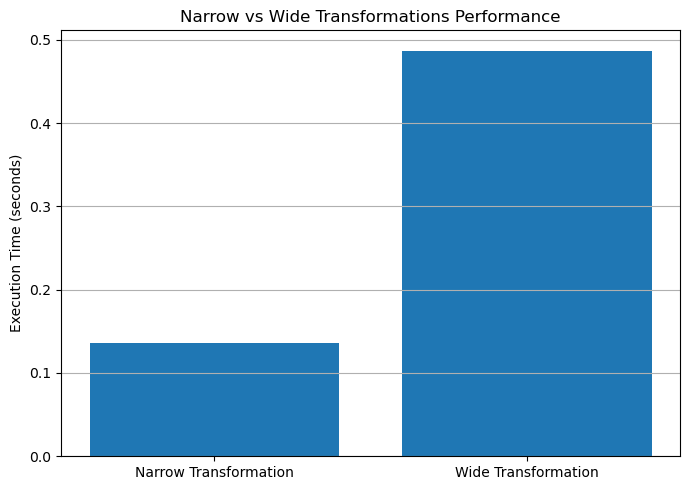

In [30]:
# Bar chart
labels = ["Narrow Transformation", "Wide Transformation"]
times = [narrow_time, wide_time]

plt.figure(figsize=(7, 5))
plt.bar(labels, times)
plt.ylabel("Execution Time (seconds)")
plt.title("Narrow vs Wide Transformations Performance")
plt.grid(axis="y")

plt.tight_layout()
plt.show()